# Explorative Analyse und Data Proprocessing:

In [1]:
import pandas as pd
import matplotlib
import numpy as np
#%matplotlib inline

In [2]:
#Zusammenstellen eines Dataframe mit allen ausgewählten Zählern
df3310 = pd.read_csv('../data/bzm_telraam_9000003310.csv.gz.csv')
df4118 = pd.read_csv('../data/bzm_telraam_9000004118.csv.gz.csv')
df4602 = pd.read_csv('../data/bzm_telraam_9000004602.csv.gz.csv')
df4685 = pd.read_csv('../data/bzm_telraam_9000004685.csv.gz.csv')
df5444 = pd.read_csv('../data/bzm_telraam_9000005444.csv.gz.csv')
df5832 = pd.read_csv('../data/bzm_telraam_9000005832.csv.gz.csv')

df_zaehler= pd.concat([df3310, df4118, df4602, df4685, df5444, df5832], ignore_index=True)

In [3]:
#Anzeige der ersten Zeilen
df_zaehler.head()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,heavy_total,v85,car_speed0,car_speed10,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70
0,9000003310,2022-03-18 07:00,0.752500,3,1,4,19,15,33,73,...,0,24.5,8.77,47.37,36.84,6.14,0.88,0.0,0.00,0.00
1,9000003310,2022-03-18 08:00,0.797222,6,3,9,25,18,43,99,...,0,20.0,12.90,65.16,18.71,2.58,0.00,0.0,0.00,0.65
2,9000003310,2022-03-18 09:00,0.795833,0,1,1,23,13,35,83,...,0,21.0,16.18,54.41,26.47,1.47,0.74,0.0,0.74,0.00
3,9000003310,2022-03-18 10:00,0.805556,1,4,5,15,14,29,81,...,0,21.0,11.29,59.68,25.81,3.23,0.00,0.0,0.00,0.00
4,9000003310,2022-03-18 11:00,0.596667,3,0,3,30,18,49,77,...,0,22.5,18.18,45.45,32.47,1.30,1.30,1.3,0.00,0.00


In [4]:
# Überprüfen der Plausibilität von ped_total

df_zaehler["summe_ped"]=df_zaehler["ped_lft"]+df_zaehler["ped_rgt"]
df_zaehler["summe_ped_valid"]=df_zaehler["ped_total"]==df_zaehler["summe_ped"]
plausibel_false_ped = (df_zaehler["summe_ped_valid"]==False).sum()
print(plausibel_false_ped)


df_notPlausible_ped=df_zaehler[df_zaehler["summe_ped_valid"]==False]
df_notPlausible_ped_copy= df_notPlausible_ped.copy()
df_notPlausible_ped_copy["ped_total_fehler"]=df_notPlausible_ped["ped_total"]-df_notPlausible_ped["summe_ped"]
df_notPlausible_ped_copy.describe()



12058


,segment_id,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,car_rgt,...,car_speed0,car_speed10,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70,summe_ped,ped_total_fehler
count,1.205800e+04,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,...,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000,12058.000000
mean,9.000005e+09,0.713829,6.983828,7.499088,14.508625,33.940206,34.768121,68.701609,62.433488,94.103666,...,10.748301,30.532991,37.770582,12.013266,3.932850,1.852632,1.028051,2.245360,14.482916,0.025709
std,7.964397e+02,0.119722,8.793993,8.923674,15.933931,25.092857,27.078850,48.451469,52.697253,100.008196,...,11.130583,14.585219,13.091415,10.235422,6.198582,4.267423,2.941374,5.326167,16.003112,0.999711
min,9.000003e+09,0.034722,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-1.000000
25%,9.000004e+09,0.693056,2.000000,2.000000,5.000000,16.000000,13.000000,31.000000,26.000000,29.000000,...,3.770000,20.755000,30.000000,5.000000,0.000000,0.000000,0.000000,0.000000,6.000000,-1.000000
50%,9.000005e+09,0.763889,4.000000,5.000000,9.000000,29.000000,29.000000,59.000000,50.000000,55.000000,...,7.870000,32.350000,38.460000,8.840000,1.680000,0.000000,0.000000,0.000000,9.000000,1.000000
75%,9.000005e+09,0.782222,9.000000,10.000000,19.000000,46.000000,50.000000,96.000000,84.000000,118.000000,...,14.067500,40.910000,46.340000,16.130000,4.350000,1.650000,0.720000,2.040000,19.000000,1.000000
max,9.000006e+09,0.994444,424.000000,189.000000,430.000000,423.000000,335.000000,494.000000,580.000000,697.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,431.000000,1.000000


In [5]:
# Überprüfen der Plausibilität von bike_total
df_zaehler["summe_bike"]=df_zaehler["bike_lft"]+df_zaehler["bike_rgt"]
df_zaehler["summe_bike_valid"]=df_zaehler["bike_total"]==df_zaehler["summe_bike"]
plausibel_false_bike = (df_zaehler["summe_bike_valid"]==False).sum()
print(plausibel_false_bike)

df_notPlausible_bike=df_zaehler[df_zaehler["summe_bike_valid"]==False]
df_notPlausible_bike_copy= df_notPlausible_bike.copy()
df_notPlausible_bike_copy["bike_total_fehler"]=df_notPlausible_bike["bike_total"]-df_notPlausible_bike["summe_bike"]
df_notPlausible_bike_copy.describe()

16042


,segment_id,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,car_rgt,...,car_speed10,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70,summe_ped,summe_bike,bike_total_fehler
count,1.604200e+04,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,...,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000,16042.000000
mean,9.000004e+09,0.686783,5.500873,5.804887,11.311682,30.993829,31.278893,62.253023,57.827079,83.270041,...,30.388013,36.587982,12.099614,4.061441,1.880833,1.081328,2.439709,11.305760,62.272722,-0.019698
std,7.900071e+02,0.150918,8.623823,8.155811,15.074388,24.647961,26.528800,47.653527,49.852993,92.606467,...,15.629535,14.309382,10.956450,6.848437,4.580015,3.322446,6.059517,15.085785,47.650891,0.999837
min,9.000003e+09,0.013611,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-1.000000
25%,9.000004e+09,0.651111,0.000000,1.000000,2.000000,13.000000,10.000000,25.000000,23.000000,25.000000,...,19.610000,27.870000,4.730000,0.000000,0.000000,0.000000,0.000000,2.000000,25.000000,-1.000000
50%,9.000005e+09,0.751389,3.000000,3.000000,6.000000,25.000000,24.000000,51.000000,46.000000,50.000000,...,31.850000,37.500000,8.820000,1.560000,0.000000,0.000000,0.000000,6.000000,51.000000,-1.000000
75%,9.000005e+09,0.780000,7.000000,8.000000,15.000000,42.000000,46.000000,88.000000,77.000000,96.000000,...,41.230000,46.150000,16.295000,4.357500,1.590000,0.600000,1.980000,15.000000,88.000000,1.000000
max,9.000006e+09,0.980000,424.000000,201.000000,430.000000,251.000000,214.000000,337.000000,533.000000,665.000000,...,100.000000,133.330000,100.000000,100.000000,100.000000,100.000000,100.000000,431.000000,338.000000,1.000000


In [6]:
# Überprüfen der Plausibilität von car_total

df_zaehler["summe_car"]=df_zaehler["car_lft"]+df_zaehler["car_rgt"]
df_zaehler["summe_car_valid"]=df_zaehler["car_total"]==df_zaehler["summe_car"]
plausibel_false_car = (df_zaehler["summe_car_valid"]==False).sum()
print(plausibel_false_car)

df_notPlausible_car=df_zaehler[df_zaehler["summe_car_valid"]==False]
df_notPlausible_car_copy= df_notPlausible_car.copy()
df_notPlausible_car_copy["car_total_fehler"]=df_notPlausible_car["car_total"]-df_notPlausible_car["summe_car"]
df_notPlausible_car_copy.describe()

17854


,segment_id,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,car_rgt,...,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70,summe_ped,summe_bike,summe_car,car_total_fehler
count,1.785400e+04,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000,...,17854.00000,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000,17854.000000
mean,9.000004e+09,0.699189,7.432340,10.520948,17.953792,29.683264,29.395430,59.074493,81.075557,106.376498,...,36.33543,13.185139,4.344023,1.903986,1.043087,2.383421,17.953288,59.078694,187.452056,0.056906
std,8.060720e+02,0.174300,12.822613,26.338710,37.542017,24.273574,26.180565,46.818908,107.760635,134.765610,...,14.30217,11.522237,6.699701,4.358471,3.135891,6.142767,37.547260,46.814340,231.459711,0.998408
min,9.000003e+09,0.005833,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-1.000000
25%,9.000004e+09,0.654513,0.000000,0.000000,2.000000,12.000000,9.000000,23.000000,23.000000,25.000000,...,27.50000,4.880000,0.000000,0.000000,0.000000,0.000000,2.000000,23.000000,51.000000,-1.000000
50%,9.000005e+09,0.756667,3.000000,3.000000,6.000000,24.000000,22.000000,48.000000,48.000000,52.000000,...,37.06000,9.760000,1.750000,0.000000,0.000000,0.000000,6.500000,49.000000,105.000000,1.000000
75%,9.000005e+09,0.783889,8.000000,9.000000,18.000000,41.000000,43.000000,84.000000,87.000000,120.000000,...,45.76000,19.050000,5.560000,1.740000,0.600000,1.790000,18.000000,84.000000,214.000000,1.000000
max,9.000006e+09,1.000560,249.000000,488.000000,589.000000,251.000000,286.000000,356.000000,675.000000,779.000000,...,100.00000,100.000000,100.000000,75.000000,60.000000,100.000000,589.000000,356.000000,1317.000000,1.000000


In [7]:
#Überprüfen von Plausibilität Geschwindigkeit
df_zaehler["summe_carspeed"]=df_zaehler["car_speed10"]+df_zaehler["car_speed20"]+df_zaehler["car_speed30"]+df_zaehler["car_speed40"]+df_zaehler["car_speed50"]+df_zaehler["car_speed60"]+df_zaehler["car_speed70"]
plausibel_false_carspeed = not (df_zaehler["summe_carspeed"]==100).any()
print(plausibel_false_carspeed)


False


In [8]:
# Stündliche Werte für ped_total, wie unter Datengrundlage - Telraam erklärt 
df_zaehler['pedtotal_corrected'] = (df_zaehler['ped_total'] * (1 - df_zaehler['uptime'])) + df_zaehler['ped_total']

In [9]:
# Stündliche Werte für car_total, wie unter Datengrundlage - Telraam erklärt 
df_zaehler['cartotal_corrected'] = (df_zaehler['car_total'] * (1 - df_zaehler['uptime'])) + df_zaehler['car_total']

In [10]:
# Stündliche Werte für bike_total, wie unter Datengrundlage - Telraam erklärt 
df_zaehler['biketotal_corrected'] = (df_zaehler['bike_total'] * (1 - df_zaehler['uptime'])) + df_zaehler['bike_total']

In [11]:
#Wir haben einen hohen Wert rausgeworfen. 
df_zaehler=df_zaehler.drop(df_zaehler[df_zaehler['ped_total'] == 1800].index)

In [12]:
#Datum umwandeln in datetime Format
df_zaehler["date_local"] = pd.to_datetime (df_zaehler["date_local"], format="%Y-%m-%d %H:%M")
                                                    

In [13]:
df_zaehler.head()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,summe_ped,summe_ped_valid,summe_bike,summe_bike_valid,summe_car,summe_car_valid,summe_carspeed,pedtotal_corrected,cartotal_corrected,biketotal_corrected
0,9000003310,2022-03-18 07:00:00,0.752500,3,1,4,19,15,33,73,...,4,True,34,False,151,True,91.23,4.990000,188.372500,41.167500
1,9000003310,2022-03-18 08:00:00,0.797222,6,3,9,25,18,43,99,...,9,True,43,True,194,True,87.10,10.825002,233.338932,51.719454
2,9000003310,2022-03-18 09:00:00,0.795833,0,1,1,23,13,35,83,...,1,True,36,False,171,True,83.83,1.204167,205.912557,42.145845
3,9000003310,2022-03-18 10:00:00,0.805556,1,4,5,15,14,29,81,...,5,True,29,True,154,True,88.72,5.972220,183.944376,34.638876
4,9000003310,2022-03-18 11:00:00,0.596667,3,0,3,30,18,49,77,...,3,True,48,False,129,True,81.82,4.209999,181.029957,68.763317


In [14]:
#Daten rausfiltern, die weniger als 30 Minuten Datenaufnahme pro Stunde haben
df_zaehler = df_zaehler.drop(df_zaehler[df_zaehler["uptime"]<= 0.5].index)
#Daten rausfiltern, in denen uptime mehr als 100 % ist
df_zaehler = df_zaehler.drop(df_zaehler[df_zaehler["uptime"]> 1].index)

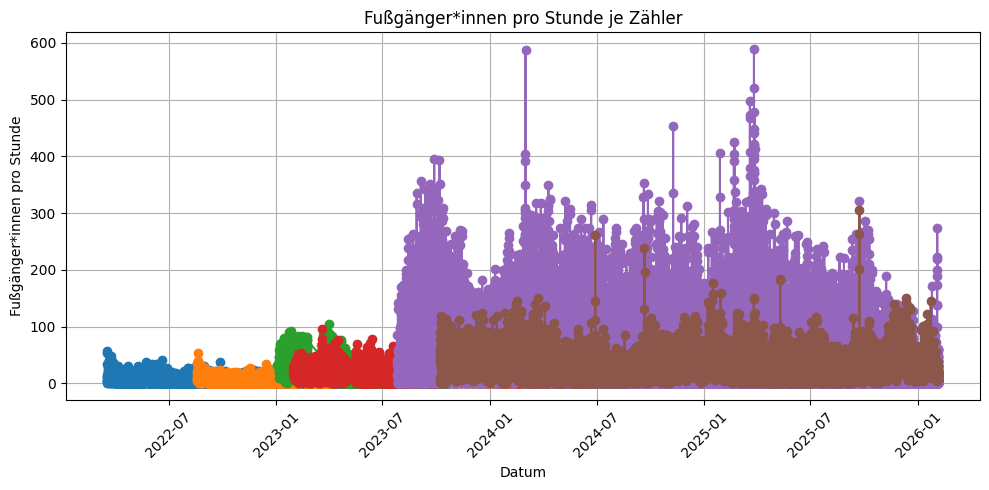

In [15]:
# Graph der Zielvariable "pedtotal_corrected" von allen Zählern 
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 5))
for zaehler, variable in df_zaehler.groupby('segment_id'):
    plt.plot(variable['date_local'], variable['pedtotal_corrected'], marker='o', label=zaehler)


plt.title('Fußgänger*innen pro Stunde je Zähler')
plt.xlabel('Datum')
plt.ylabel('Fußgänger*innen pro Stunde')
plt.grid(True)
plt.xticks(rotation=45)
#plt.savefig("../images/ProStundeJeZaehler.jpg", format='jpg')
plt.tight_layout()

In [16]:
# Graph für jeden Zähler einzelnd
df_zaehlerId = df_zaehler['segment_id'].unique()
anzahl_zaehlerId = len(df_zaehlerId)

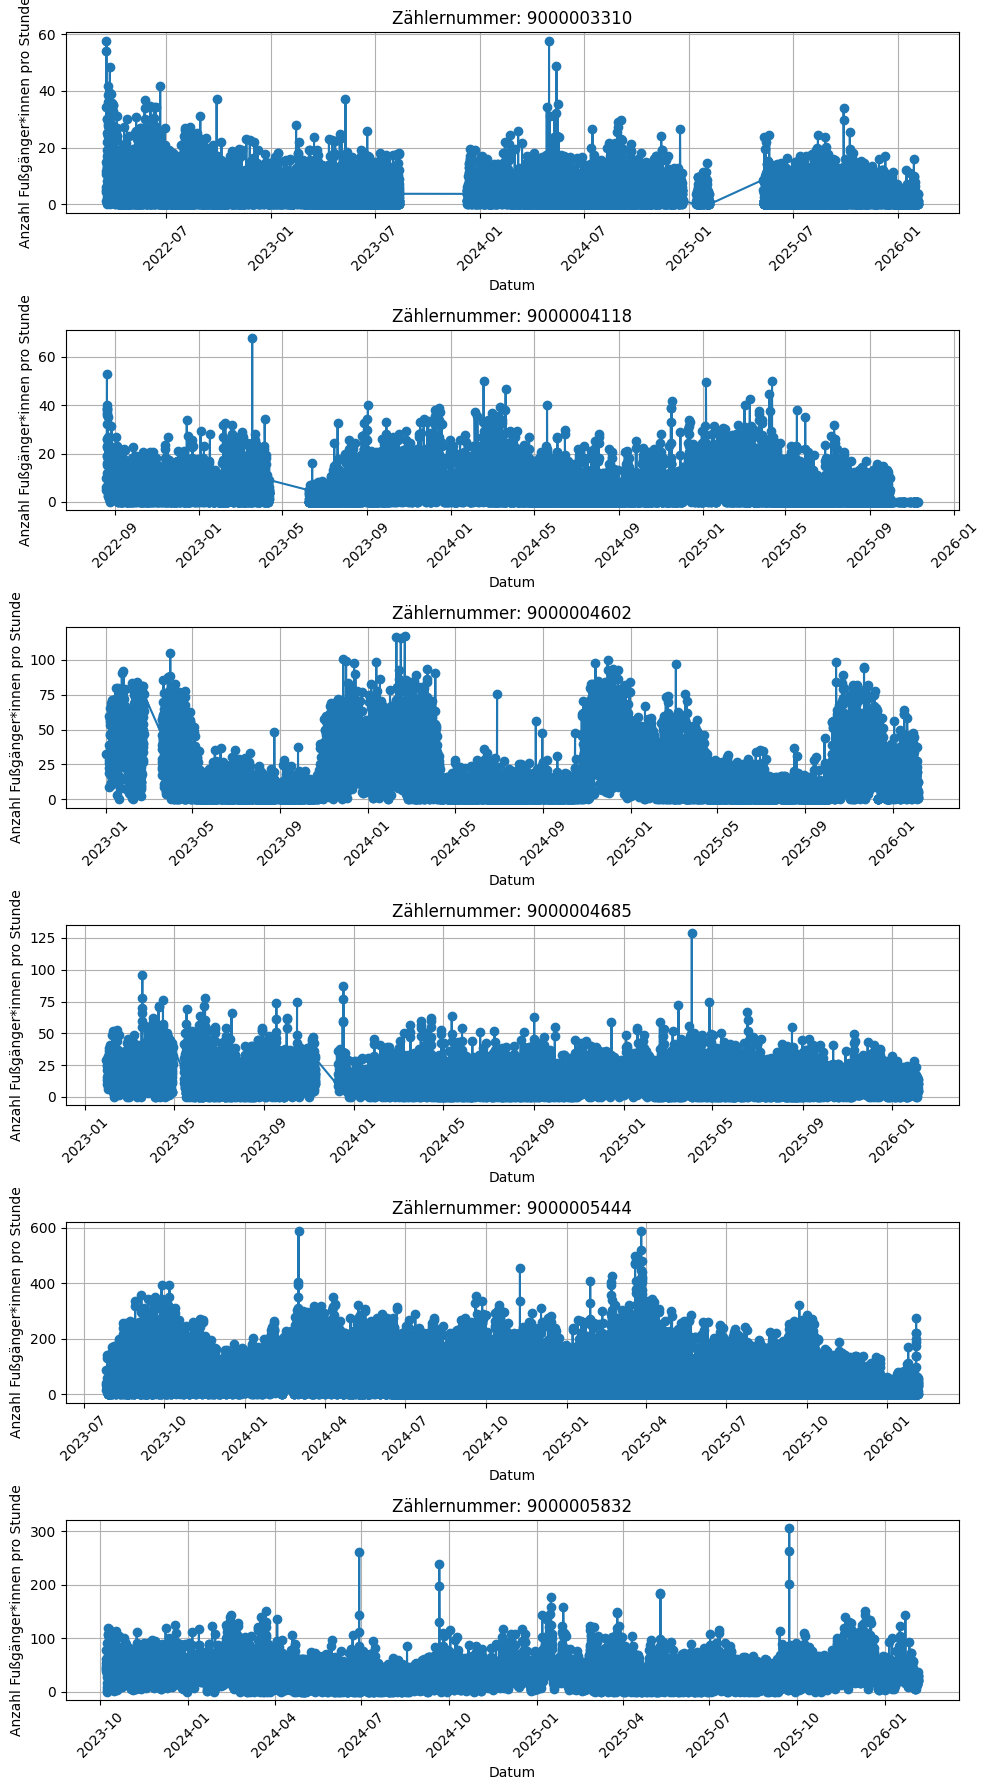

In [17]:
# Erstellen der Subplots
plt.figure(figsize=(10, anzahl_zaehlerId * 3))  # Die Größe des Gesamtplots anpassen

# Iteriere über die Zähler und erstelle für jeden einen eigenen Plot
for i, (zaehler, variable) in enumerate(df_zaehler.groupby('segment_id')):
    plt.subplot(anzahl_zaehlerId, 1, i + 1)  # Platzierung des Subplots
    plt.plot(variable['date_local'], variable['pedtotal_corrected'], marker='o', label=f'segment_id {zaehler}')

    plt.title(f'Zählernummer: {zaehler}')
    plt.xlabel('Datum')
    plt.ylabel('Anzahl Fußgänger*innen pro Stunde')
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()  # Für besseren Abstand zwischen den Subplots
#plt.savefig("../images/SubplotZaehler.jpg", format='jpg')
plt.show()

In [18]:
#Zeilen und Spaltenanzahl des Dataframe
df_zaehler.shape

(76508, 34)

In [19]:
#Datentypen im Datensatz
df_zaehler.dtypes

segment_id                      int64
date_local             datetime64[ns]
uptime                        float64
ped_lft                         int64
ped_rgt                         int64
ped_total                       int64
bike_lft                        int64
bike_rgt                        int64
bike_total                      int64
car_lft                         int64
car_rgt                         int64
car_total                       int64
heavy_lft                       int64
heavy_rgt                       int64
heavy_total                     int64
v85                           float64
car_speed0                    float64
car_speed10                   float64
car_speed20                   float64
car_speed30                   float64
car_speed40                   float64
car_speed50                   float64
car_speed60                   float64
car_speed70                   float64
summe_ped                       int64
summe_ped_valid                  bool
summe_bike  

In [20]:
#Statistischer Überblick über Datensatz
df_zaehler.describe()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,car_speed50,car_speed60,car_speed70,summe_ped,summe_bike,summe_car,summe_carspeed,pedtotal_corrected,cartotal_corrected,biketotal_corrected
count,7.650800e+04,76508,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000,...,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000,76508.000000
mean,9.000005e+09,2024-07-31 07:57:56.248235520,0.790806,8.005098,11.765083,19.776376,26.375229,25.401252,51.772298,95.846042,...,1.796460,0.914732,1.902942,19.770181,51.776481,208.395436,80.602018,21.953018,237.473119,64.660179
min,9.000003e+09,2022-03-18 07:00:00,0.500278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000004e+09,2023-11-28 09:45:00,0.720000,0.000000,0.000000,1.000000,9.000000,5.000000,16.000000,20.000000,...,0.000000,0.000000,0.000000,1.000000,16.000000,43.000000,80.000000,1.294167,54.286661,19.088337
50%,9.000005e+09,2024-08-19 17:00:00,0.775000,3.000000,3.000000,6.000000,21.000000,18.000000,40.000000,48.000000,...,0.000000,0.000000,0.000000,6.000000,40.000000,107.000000,90.470000,7.360002,136.111129,48.311120
75%,9.000005e+09,2025-05-25 05:00:00,0.800278,9.000000,10.000000,19.000000,38.000000,38.000000,76.000000,100.000000,...,1.890000,0.610000,1.280000,19.000000,76.000000,259.000000,95.700000,23.313257,320.488173,95.812500
max,9.000006e+09,2026-02-04 16:00:00,1.000000,199.000000,488.000000,589.000000,321.000000,214.000000,371.000000,650.000000,...,100.000000,100.000000,100.000000,589.000000,371.000000,1317.000000,150.000000,589.327484,1553.711992,487.200000
std,8.261182e+02,NaN,0.130896,13.771818,26.131983,38.443636,23.776163,25.483724,46.238564,127.378127,...,3.956159,2.849524,5.304619,38.448987,46.239290,254.867438,27.158166,39.125116,262.635254,59.335254


In [21]:
#Fehlende Werte im Datensatz werden angezeigt. V85 steht für die Geschwindigkeit der Autos und interessiert uns hier nicht.
df_zaehler.isna().sum()

segment_id                0
date_local                0
uptime                    0
ped_lft                   0
ped_rgt                   0
ped_total                 0
bike_lft                  0
bike_rgt                  0
bike_total                0
car_lft                   0
car_rgt                   0
car_total                 0
heavy_lft                 0
heavy_rgt                 0
heavy_total               0
v85                    6303
car_speed0                0
car_speed10               0
car_speed20               0
car_speed30               0
car_speed40               0
car_speed50               0
car_speed60               0
car_speed70               0
summe_ped                 0
summe_ped_valid           0
summe_bike                0
summe_bike_valid          0
summe_car                 0
summe_car_valid           0
summe_carspeed            0
pedtotal_corrected        0
cartotal_corrected        0
biketotal_corrected       0
dtype: int64

In [22]:
#Einlesen der stündlichen Wetterdaten
df_regen = pd.read_csv('../data/produkt_rr_stunde_19950901_20241231_00433.txt',sep=';')
df_temp = pd.read_csv('../data/produkt_tu_stunde_19510101_20241231_00433.txt',sep=';')

In [23]:
df_regen.head()

,STATIONS_ID,MESS_DATUM,QN_8,R1,RS_IND,WRTR,eor
0,433,1995090100,1,1.1,1,-999,eor
1,433,1995090101,1,0.2,1,-999,eor
2,433,1995090102,1,1.1,1,-999,eor
3,433,1995090103,1,2.9,1,-999,eor
4,433,1995090104,1,1.4,1,-999,eor


In [24]:
df_temp.head()


,STATIONS_ID,MESS_DATUM,QN_9,TT_TU,RF_TU,eor
0,433,1951010101,5,-10.7,88.0,eor
1,433,1951010102,5,-11.0,87.0,eor
2,433,1951010103,5,-11.2,87.0,eor
3,433,1951010104,5,-11.4,87.0,eor
4,433,1951010105,5,-10.8,86.0,eor


In [25]:
df_regen.describe()

,STATIONS_ID,MESS_DATUM,QN_8,R1,RS_IND,WRTR
count,255860.0,2.558600e+05,255860.000000,255860.000000,255860.000000,255860.000000
mean,433.0,2.009916e+09,2.349191,-0.987044,-0.825827,-747.711921
std,0.0,8.467763e+06,0.937053,32.380248,32.385199,433.867316
min,433.0,1.995090e+09,1.000000,-999.000000,-999.000000,-999.000000
25%,433.0,2.003011e+09,1.000000,0.000000,0.000000,-999.000000
50%,433.0,2.010050e+09,3.000000,0.000000,0.000000,-999.000000
75%,433.0,2.017091e+09,3.000000,0.000000,0.000000,0.000000
max,433.0,2.024123e+09,3.000000,31.700000,1.000000,8.000000


In [26]:
df_temp.describe()

,STATIONS_ID,MESS_DATUM,QN_9,TT_TU,RF_TU
count,560119.0,5.601190e+05,560119.000000,560119.000000,560119.000000
mean,433.0,1.989425e+09,4.656430,9.362452,73.401011
std,0.0,2.237915e+07,2.392067,25.003761,40.604880
min,433.0,1.951010e+09,1.000000,-999.000000,-999.000000
25%,433.0,1.966122e+09,3.000000,3.600000,63.000000
50%,433.0,1.992121e+09,3.000000,9.900000,79.000000
75%,433.0,2.009010e+09,5.000000,16.000000,89.000000
max,433.0,2.024123e+09,10.000000,38.100000,100.000000


In [27]:
#Mess_datum in ein Datum umwandeln
df_regen["MESS_DATUM"] = pd.to_datetime(df_regen["MESS_DATUM"],format="%Y%m%d%H") #,format="%Y%m%d%H" hiermit wird das Datum umgewandelt, damit es in Zukunft einfacher zu handhaben ist. Das Format ist JahrMonatTag, deswegen %Y%md%Y%m%d
df_temp["MESS_DATUM"] = pd.to_datetime(df_temp["MESS_DATUM"], format="%Y%m%d%H")#

In [28]:
df_wetter = pd.merge(
    df_regen[["MESS_DATUM", "  R1"]],
    df_temp[["MESS_DATUM", "TT_TU"]],
    on=["MESS_DATUM"],
    how="inner" #inner schmeißt alles raus was nicht in beiden DataFrames steht
)

In [29]:
df_wetter.head()

,MESS_DATUM,R1,TT_TU
0,1995-09-01 00:00:00,1.1,12.6
1,1995-09-01 01:00:00,0.2,12.8
2,1995-09-01 02:00:00,1.1,12.9
3,1995-09-01 03:00:00,2.9,12.7
4,1995-09-01 04:00:00,1.4,12.8


In [30]:
# Umwandeln von Messdatum in Mikrosekunden (nicht notwendig zum mergen)
#df_wetter["MESS_DATUM"]=df_wetter["MESS_DATUM"].astype('datetime64[us]')

In [31]:
#Datentypen im Datensatz
df_wetter.dtypes

MESS_DATUM    datetime64[ns]
  R1                 float64
TT_TU                float64
dtype: object

In [32]:
df_wetter.head()

,MESS_DATUM,R1,TT_TU
0,1995-09-01 00:00:00,1.1,12.6
1,1995-09-01 01:00:00,0.2,12.8
2,1995-09-01 02:00:00,1.1,12.9
3,1995-09-01 03:00:00,2.9,12.7
4,1995-09-01 04:00:00,1.4,12.8


In [33]:
df_wetter.isna().sum()

MESS_DATUM    0
  R1          0
TT_TU         0
dtype: int64

In [34]:
df_wetter.describe()


,MESS_DATUM,R1,TT_TU
count,255053,255053.000000,255053.000000
mean,2010-05-22 06:18:36.219766528,-0.986511,9.530385
min,1995-09-01 00:00:00,-999.000000,-999.000000
25%,2003-02-04 13:00:00,0.000000,4.300000
50%,2010-05-18 01:00:00,0.000000,10.400000
75%,2017-09-20 00:00:00,0.000000,16.700000
max,2024-12-31 23:00:00,31.700000,38.100000
std,NaN,32.371111,33.563622


In [35]:
df_modellvariablen = pd.merge(
    df_zaehler,
    df_wetter, #[["  R1", "MESS_DATUM", "TT_TU"]]
    left_on=["date_local"],
    right_on=["MESS_DATUM"],
    how="inner" #inner schmeißt alles raus was nicht in beiden DataFrames steht
)

In [36]:
# nicht notwendig - merge funktioniert
# print (df_zaehler["date_local"].dt.tz)

In [37]:
df_modellvariablen.describe()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,summe_ped,summe_bike,summe_car,summe_carspeed,pedtotal_corrected,cartotal_corrected,biketotal_corrected,MESS_DATUM,R1,TT_TU
count,4.751500e+04,47515,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,...,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515,47515.000000,47515.000000
mean,9.000005e+09,2023-12-31 20:48:17.426076160,0.775667,8.146038,11.886415,20.038430,27.997664,26.260360,54.255330,100.442871,...,20.032453,54.258024,218.503336,84.282076,22.285725,252.073076,67.982573,2023-12-31 20:48:17.426076160,-6.371232,12.141650
min,9.000003e+09,2022-03-18 07:00:00,0.500278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-03-18 07:00:00,-999.000000,-999.000000
25%,9.000004e+09,2023-07-05 14:30:00,0.711389,0.000000,0.000000,2.000000,10.000000,7.000000,20.000000,25.000000,...,2.000000,20.000000,55.000000,82.500000,2.696666,69.782216,23.520423,2023-07-05 14:30:00,0.000000,8.750000
50%,9.000005e+09,2024-03-06 14:00:00,0.770833,3.000000,3.000000,6.000000,23.000000,19.000000,43.000000,56.000000,...,6.000000,43.000000,120.000000,91.270000,7.789998,152.555013,52.028912,2024-03-06 14:00:00,0.000000,15.700000
75%,9.000005e+09,2024-07-23 06:00:00,0.794167,9.000000,10.000000,18.000000,39.000000,38.000000,77.000000,108.000000,...,18.000000,77.000000,271.000000,96.000000,22.900282,338.474182,97.976658,2024-07-23 06:00:00,0.000000,21.200000
max,9.000006e+09,2024-12-31 23:00:00,1.000000,142.000000,488.000000,588.000000,321.000000,214.000000,371.000000,650.000000,...,588.000000,371.000000,1277.000000,150.000000,588.489804,1553.711992,487.200000,2024-12-31 23:00:00,23.100000,37.700000
std,8.264865e+02,NaN,0.122254,13.913277,26.415143,38.885816,23.731418,25.084891,45.650901,125.390565,...,38.891606,45.651224,253.116458,21.903503,39.536710,262.468666,58.806231,NaN,79.918663,54.557787


In [38]:
df_modellvariablen.shape

(47515, 37)

In [39]:
df_zaehler.shape

(76508, 34)

In [40]:
print(df_modellvariablen.columns)

Index(['segment_id', 'date_local', 'uptime', 'ped_lft', 'ped_rgt', 'ped_total',
       'bike_lft', 'bike_rgt', 'bike_total', 'car_lft', 'car_rgt', 'car_total',
       'heavy_lft', 'heavy_rgt', 'heavy_total', 'v85', 'car_speed0',
       'car_speed10', 'car_speed20', 'car_speed30', 'car_speed40',
       'car_speed50', 'car_speed60', 'car_speed70', 'summe_ped',
       'summe_ped_valid', 'summe_bike', 'summe_bike_valid', 'summe_car',
       'summe_car_valid', 'summe_carspeed', 'pedtotal_corrected',
       'cartotal_corrected', 'biketotal_corrected', 'MESS_DATUM', '  R1',
       'TT_TU'],
      dtype='object')


In [41]:
countminus= (df_modellvariablen["  R1"]==-999.000000).sum()

In [42]:
countminus2= (df_modellvariablen["TT_TU"]==-999.000000).sum()

In [43]:
countminus

np.int64(306)

In [44]:
countminus2

np.int64(135)

In [45]:
# -999 Werte von Temperatur und Niederschlag durch NaN ersetzen und mit Median füllen 
df_modellvariablen["  R1"] = df_modellvariablen["  R1"].replace(-999, np.nan).fillna(df_modellvariablen["  R1"].median())
df_modellvariablen["TT_TU"] = df_modellvariablen["TT_TU"].replace(-999, np.nan).fillna(df_modellvariablen["TT_TU"].median())


In [46]:
# R1 und TT_TU umbenennen
df_modellvariablen=df_modellvariablen.rename(columns={"  R1": "niederschlag", "TT_TU" : "temperatur" })


In [47]:
df_modellvariablen.describe()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,summe_ped,summe_bike,summe_car,summe_carspeed,pedtotal_corrected,cartotal_corrected,biketotal_corrected,MESS_DATUM,niederschlag,temperatur
count,4.751500e+04,47515,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,...,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515.000000,47515,47515.000000,47515.000000
mean,9.000005e+09,2023-12-31 20:48:17.426076160,0.775667,8.146038,11.886415,20.038430,27.997664,26.260360,54.255330,100.442871,...,20.032453,54.258024,218.503336,84.282076,22.285725,252.073076,67.982573,2023-12-31 20:48:17.426076160,0.062399,15.024624
min,9.000003e+09,2022-03-18 07:00:00,0.500278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-03-18 07:00:00,0.000000,-9.900000
25%,9.000004e+09,2023-07-05 14:30:00,0.711389,0.000000,0.000000,2.000000,10.000000,7.000000,20.000000,25.000000,...,2.000000,20.000000,55.000000,82.500000,2.696666,69.782216,23.520423,2023-07-05 14:30:00,0.000000,8.800000
50%,9.000005e+09,2024-03-06 14:00:00,0.770833,3.000000,3.000000,6.000000,23.000000,19.000000,43.000000,56.000000,...,6.000000,43.000000,120.000000,91.270000,7.789998,152.555013,52.028912,2024-03-06 14:00:00,0.000000,15.700000
75%,9.000005e+09,2024-07-23 06:00:00,0.794167,9.000000,10.000000,18.000000,39.000000,38.000000,77.000000,108.000000,...,18.000000,77.000000,271.000000,96.000000,22.900282,338.474182,97.976658,2024-07-23 06:00:00,0.000000,21.200000
max,9.000006e+09,2024-12-31 23:00:00,1.000000,142.000000,488.000000,588.000000,321.000000,214.000000,371.000000,650.000000,...,588.000000,371.000000,1277.000000,150.000000,588.489804,1553.711992,487.200000,2024-12-31 23:00:00,23.100000,37.700000
std,8.264865e+02,NaN,0.122254,13.913277,26.415143,38.885816,23.731418,25.084891,45.650901,125.390565,...,38.891606,45.651224,253.116458,21.903503,39.536710,262.468666,58.806231,NaN,0.499181,7.958833


In [48]:
df_modellvariablen.head()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,summe_bike_valid,summe_car,summe_car_valid,summe_carspeed,pedtotal_corrected,cartotal_corrected,biketotal_corrected,MESS_DATUM,niederschlag,temperatur
0,9000003310,2022-03-18 07:00:00,0.752500,3,1,4,19,15,33,73,...,False,151,True,91.23,4.990000,188.372500,41.167500,2022-03-18 07:00:00,0.0,5.6
1,9000003310,2022-03-18 08:00:00,0.797222,6,3,9,25,18,43,99,...,True,194,True,87.10,10.825002,233.338932,51.719454,2022-03-18 08:00:00,0.0,6.3
2,9000003310,2022-03-18 09:00:00,0.795833,0,1,1,23,13,35,83,...,False,171,True,83.83,1.204167,205.912557,42.145845,2022-03-18 09:00:00,0.0,7.4
3,9000003310,2022-03-18 10:00:00,0.805556,1,4,5,15,14,29,81,...,True,154,True,88.72,5.972220,183.944376,34.638876,2022-03-18 10:00:00,0.0,8.7
4,9000003310,2022-03-18 11:00:00,0.596667,3,0,3,30,18,49,77,...,False,129,True,81.82,4.209999,181.029957,68.763317,2022-03-18 11:00:00,0.0,9.9


  ### Variablen über datetime hinzufügen

In [49]:

df_modellvariablen["stunde"]= df_modellvariablen["date_local"].dt.hour 
df_modellvariablen["DOY"]=df_modellvariablen["date_local"].dt.day_of_year # DOY = Tag des Jahres (bis auf die Stunde genau)

In [50]:
df_modellvariablen["tag"] = df_zaehler["date_local"].dt.day
df_modellvariablen["monat"] = df_zaehler["date_local"].dt.month
df_modellvariablen["jahr"] = df_zaehler["date_local"].dt.year

In [51]:
# Wochentag Feature hinzufügen (0=Montag, 6=Sonntag) 
df_modellvariablen["wochentag"] = df_modellvariablen["date_local"].dt.dayofweek 
df_modellvariablen["wochenende"] = (df_modellvariablen["wochentag"] >= 5).astype(int) # zu 0 oder 1 -> Kategorie




In [52]:
tage=["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]
for i in range (7):
    df_modellvariablen[tage[i]]=(df_modellvariablen["wochentag"] == i).astype(float)

In [53]:
df_modellvariablen.head()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,jahr,wochentag,wochenende,Mo,Di,Mi,Do,Fr,Sa,So
0,9000003310,2022-03-18 07:00:00,0.752500,3,1,4,19,15,33,73,...,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,9000003310,2022-03-18 08:00:00,0.797222,6,3,9,25,18,43,99,...,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,9000003310,2022-03-18 09:00:00,0.795833,0,1,1,23,13,35,83,...,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,9000003310,2022-03-18 10:00:00,0.805556,1,4,5,15,14,29,81,...,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,9000003310,2022-03-18 11:00:00,0.596667,3,0,3,30,18,49,77,...,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Übersicht Datensatz mit Modellvariablen

In [54]:
pd.set_option('display.max_columns', None)
df_modellvariablen.head()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,car_rgt,car_total,heavy_lft,heavy_rgt,heavy_total,v85,car_speed0,car_speed10,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70,summe_ped,summe_ped_valid,summe_bike,summe_bike_valid,summe_car,summe_car_valid,summe_carspeed,pedtotal_corrected,cartotal_corrected,biketotal_corrected,MESS_DATUM,niederschlag,temperatur,stunde,DOY,tag,monat,jahr,wochentag,wochenende,Mo,Di,Mi,Do,Fr,Sa,So
0,9000003310,2022-03-18 07:00:00,0.752500,3,1,4,19,15,33,73,78,151,0,0,0,24.5,8.77,47.37,36.84,6.14,0.88,0.0,0.00,0.00,4,True,34,False,151,True,91.23,4.990000,188.372500,41.167500,2022-03-18 07:00:00,0.0,5.6,7,77,18.0,3.0,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,9000003310,2022-03-18 08:00:00,0.797222,6,3,9,25,18,43,99,95,194,0,0,0,20.0,12.90,65.16,18.71,2.58,0.00,0.0,0.00,0.65,9,True,43,True,194,True,87.10,10.825002,233.338932,51.719454,2022-03-18 08:00:00,0.0,6.3,8,77,18.0,3.0,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,9000003310,2022-03-18 09:00:00,0.795833,0,1,1,23,13,35,83,88,171,0,0,0,21.0,16.18,54.41,26.47,1.47,0.74,0.0,0.74,0.00,1,True,36,False,171,True,83.83,1.204167,205.912557,42.145845,2022-03-18 09:00:00,0.0,7.4,9,77,18.0,3.0,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,9000003310,2022-03-18 10:00:00,0.805556,1,4,5,15,14,29,81,73,154,0,0,0,21.0,11.29,59.68,25.81,3.23,0.00,0.0,0.00,0.00,5,True,29,True,154,True,88.72,5.972220,183.944376,34.638876,2022-03-18 10:00:00,0.0,8.7,10,77,18.0,3.0,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,9000003310,2022-03-18 11:00:00,0.596667,3,0,3,30,18,49,77,52,129,0,0,0,22.5,18.18,45.45,32.47,1.30,1.30,1.3,0.00,0.00,3,True,48,False,129,True,81.82,4.209999,181.029957,68.763317,2022-03-18 11:00:00,0.0,9.9,11,77,18.0,3.0,2022.0,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [55]:
print(df_modellvariablen.columns)

Index(['segment_id', 'date_local', 'uptime', 'ped_lft', 'ped_rgt', 'ped_total',
       'bike_lft', 'bike_rgt', 'bike_total', 'car_lft', 'car_rgt', 'car_total',
       'heavy_lft', 'heavy_rgt', 'heavy_total', 'v85', 'car_speed0',
       'car_speed10', 'car_speed20', 'car_speed30', 'car_speed40',
       'car_speed50', 'car_speed60', 'car_speed70', 'summe_ped',
       'summe_ped_valid', 'summe_bike', 'summe_bike_valid', 'summe_car',
       'summe_car_valid', 'summe_carspeed', 'pedtotal_corrected',
       'cartotal_corrected', 'biketotal_corrected', 'MESS_DATUM',
       'niederschlag', 'temperatur', 'stunde', 'DOY', 'tag', 'monat', 'jahr',
       'wochentag', 'wochenende', 'Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So'],
      dtype='object')


# Modelling

## Testsplit für alle Modelle:

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
print(df_modellvariablen.columns)

Index(['segment_id', 'date_local', 'uptime', 'ped_lft', 'ped_rgt', 'ped_total',
       'bike_lft', 'bike_rgt', 'bike_total', 'car_lft', 'car_rgt', 'car_total',
       'heavy_lft', 'heavy_rgt', 'heavy_total', 'v85', 'car_speed0',
       'car_speed10', 'car_speed20', 'car_speed30', 'car_speed40',
       'car_speed50', 'car_speed60', 'car_speed70', 'summe_ped',
       'summe_ped_valid', 'summe_bike', 'summe_bike_valid', 'summe_car',
       'summe_car_valid', 'summe_carspeed', 'pedtotal_corrected',
       'cartotal_corrected', 'biketotal_corrected', 'MESS_DATUM',
       'niederschlag', 'temperatur', 'stunde', 'DOY', 'tag', 'monat', 'jahr',
       'wochentag', 'wochenende', 'Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So'],
      dtype='object')


In [58]:
# Features (X) und Ziel-Variable (y) definieren
X = df_modellvariablen[["niederschlag", "temperatur", "DOY", "stunde", "wochentag", "wochenende", "biketotal_corrected", "cartotal_corrected", "Mo", "Di", "Mi", "Do", "Fr", "Sa", "So","car_speed10", "car_speed20", "car_speed30", "car_speed40",
       "car_speed50", "car_speed60", "car_speed70" ]]  # Wetterdaten als Features
y = df_modellvariablen["pedtotal_corrected"]  # Fußgängerinnen als Ziel-Variable

In [59]:
# Train/Test Split (80% Training, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Baseline Modell: Mittelwert 

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [61]:
#Evaluation des BaselineModells:
baselinemodell_true_test=y_test
baselinemodell_true_train=y_train
baselinemodel_pred_train=np.full(baselinemodell_true_train.shape, y_train.mean())
baselinemodel_pred_test=np.full(baselinemodell_true_test.shape, y_test.mean())



In [62]:
modell_baseline = "Baselinemodell"
baseline_mae_train=mean_absolute_error(baselinemodell_true_train, baselinemodel_pred_train)
baseline_rmse_train=np.sqrt(mean_squared_error(baselinemodell_true_train, baselinemodel_pred_train))
baseline_r2_train=r2_score(baselinemodell_true_train, baselinemodel_pred_train)
baseline_mae_test=mean_absolute_error(baselinemodell_true_test, baselinemodel_pred_test)
baseline_rmse_test=np.sqrt(mean_squared_error(baselinemodell_true_test, baselinemodel_pred_test))
baseline_r2_test=r2_score(baselinemodell_true_test, baselinemodel_pred_test)


In [63]:
ergebnis_baseline=[
    {"Modell" : modell_baseline, "Metrik": "MAE", "Training" : baseline_mae_train, "Test":baseline_mae_test},
    {"Modell" : modell_baseline, "Metrik": "RMSE", "Training" : baseline_rmse_train,  "Test":baseline_rmse_test},
    {"Modell" : modell_baseline, "Metrik": "R²", "Training" : baseline_r2_train,  "Test":baseline_r2_test}
     ]
ergebnis_baseline_df=pd.DataFrame(ergebnis_baseline)

In [64]:
print(ergebnis_baseline_df.to_string(index=False))

        Modell Metrik  Training      Test
Baselinemodell    MAE 23.839638 23.664238
Baselinemodell   RMSE 39.630983 39.155114
Baselinemodell     R²  0.000000  0.000000


## Lineares Regressionsmodell

In [65]:
#Lineare Regression:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler



In [66]:
# Daten normalisieren mit StandardScaler
#fit transform: Fittet Standardscaler auf die Daten und wendet die Transformation auf die Daten an
# transform: nutzt dieselbe skalierung und wendet die Transformation auf die Daten an
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
# Lineares Regressionsmodell trainieren
model_linreg = LinearRegression()
model_linreg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
# Koeffizienten anzeigen / Gewichtungen
print("Modell-Koeffizienten:")
for feature, coef in zip(["niederschlag", "temperatur", "DOY", "stunde", "wochentag", "wochenende", "biketotal_corrected", "cartotal_corrected", "Mo", "Di", "Mi", "Do", "Fr", "Sa", "So","car_speed10", "car_speed20", "car_speed30", "car_speed40",
       "car_speed50", "car_speed60", "car_speed70"], model_linreg.coef_):
    #"niederschlag", "temperatur", "DOY", "stunde", "wochentag", "wochenende", "biketotal_corrected", "cartotal_corrected"
    print(f"{feature:10s}: {coef:10.4f}")
print(f"Intercept: {model_linreg.intercept_:10.4f}")

Modell-Koeffizienten:
niederschlag:    -0.4568
temperatur:    -3.7506
DOY       :     0.9572
stunde    :    -0.6277
wochentag :    -0.3154
wochenende:    -0.4333
biketotal_corrected:     3.6921
cartotal_corrected:    25.8435
Mo        :     0.2919
Di        :    -0.2157
Mi        :     0.1064
Do        :    -0.1040
Fr        :     0.4798
Sa        :     0.0551
So        :    -0.6150
car_speed10:    -3.8107
car_speed20:     0.9490
car_speed30:     4.6721
car_speed40:     0.0166
car_speed50:    -0.7733
car_speed60:    -0.5580
car_speed70:    -0.8194
Intercept:    22.3084


In [69]:
#wenn die Stunden sinkt die Anzahl der Fußganegerinnen
#Wenn die Niederschlagsmenge steigt, dann sinkt die Anzahl der Fußgängerinnen
#Intercept = Achsenabschnitt

In [70]:
# Vorhersagen machen
y_pred_train_linearr = model_linreg.predict(X_train_scaled)
y_pred_test_linearr = model_linreg.predict(X_test_scaled)


In [71]:
# Modell Lineare Regression evaluieren
modell_linearr="Lineare Regression"
train_mae_linearr = mean_absolute_error(y_train, y_pred_train_linearr)
train_rmse_linarr = np.sqrt(mean_squared_error(y_train, y_pred_train_linearr))
train_r2_linearr = r2_score(y_train, y_pred_train_linearr)

test_mae_linearr = mean_absolute_error(y_test, y_pred_test_linearr)
test_rmse_linearr = np.sqrt(mean_squared_error(y_test, y_pred_test_linearr))
test_r2_linearr = r2_score(y_test, y_pred_test_linearr)




In [72]:
ergebnis_linearr=[
    {"Modell" : modell_linearr, "Metrik": "MAE", "Training" : train_mae_linearr, "Test":test_mae_linearr},
    {"Modell" : modell_linearr, "Metrik": "RMSE", "Training" : train_rmse_linarr,  "Test":test_rmse_linearr},
    {"Modell" : modell_linearr, "Metrik": "R²", "Training" : train_r2_linearr,  "Test":test_r2_linearr}
     ]
ergebnis_linearr_df=pd.DataFrame(ergebnis_linearr)

In [73]:
print(ergebnis_linearr_df.to_string(index=False))

            Modell Metrik  Training      Test
Lineare Regression    MAE 17.972871 18.306515
Lineare Regression   RMSE 28.523709 28.674253
Lineare Regression     R²  0.481985  0.463701


## Random Forest Modell

In [74]:
from sklearn.ensemble import RandomForestRegressor



In [75]:
# Features für Random Forest
features_rf = ["segment_id","stunde", "wochentag", "wochenende", "temperatur", "niederschlag", "biketotal_corrected", "cartotal_corrected", "DOY", "car_speed10", "car_speed20", "car_speed30"]

X_rf = df_modellvariablen[features_rf]
y_rf = df_modellvariablen["pedtotal_corrected"]

# Train/Test Split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

In [76]:
# Random Forest trainieren
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_rf, y_train_rf)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [77]:
#Vorhersagen machen
y_pred_train_randomf = rf_model.predict(X_train_rf)
y_pred_test_randomf = rf_model.predict(X_test_rf)

In [78]:
# Modell Random Forest evaluieren
modell_randomf="Random Forest"

train_mae_randomf = mean_absolute_error(y_train_rf, y_pred_train_randomf)
train_rmse_randomf = np.sqrt(mean_squared_error(y_train_rf, y_pred_train_randomf))
train_r2_randomf = r2_score(y_train_rf, y_pred_train_randomf)

test_mae_randomf = mean_absolute_error(y_test_rf, y_pred_test_randomf)
test_rmse_randomf = np.sqrt(mean_squared_error(y_test_rf, y_pred_test_randomf))
test_r2_randomf = r2_score(y_test_rf, y_pred_test_randomf)


In [79]:
#Zusammenfassung Random Forest:
ergebnis_randomf=[
    {"Modell" : modell_randomf, "Metrik": "MAE", "Training" : train_mae_randomf, "Test":test_mae_randomf},
    {"Modell" : modell_randomf, "Metrik": "RMSE", "Training" : train_rmse_randomf,  "Test":test_rmse_randomf},
    {"Modell" : modell_randomf, "Metrik": "R²", "Training" : train_r2_randomf,  "Test":test_r2_randomf}
     ]
ergebnis_randomf_df=pd.DataFrame(ergebnis_randomf)

In [80]:
print(ergebnis_randomf_df.to_string(index=False))

       Modell Metrik  Training      Test
Random Forest    MAE  5.341218  8.789532
Random Forest   RMSE  9.444329 17.370965
Random Forest     R²  0.943210  0.803179


## Hyperparameter Tuning mit 5-Fold Cross-Validation

In [81]:
from sklearn.model_selection import GridSearchCV

# Mit 5-Fold Cross Validation die besten Hyperparameter bestimmen:

# Hyperparameter-Grid definieren
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Random Forest Base Model
#hier sind die Parameter drin die immer gleich sein sollen
rf_base = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# GridSearchCV mit 5-Fold Cross-Validation
# cv = 5 Folds
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error', #Metrik um die Random Forest Modell zu vergleichen
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_rf, y_train_rf)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   4.1s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   4.6s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   4.7s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   4.8s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   5.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   4.9s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   5.1s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   4.9s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   4.9s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   4.9s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=10; total time=   5.1s
[CV] END max_depth=5, min_samples_l

/Users/maryammirza/PycharmProjects/pedestrian_forecast_datascience/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/maryammirza/PycharmProjects/pedestrian_forecast_datascience/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/maryammirza/PycharmProjects/pedestrian_forecast_datascience/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn

[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=20; total time=   9.4s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=20; total time=   9.5s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=20; total time=   9.6s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=20; total time=   9.6s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=2; total time=  13.6s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=2; total time=  13.6s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5; total time=  13.3s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=2; total time=  13.8s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=2; total time=  13.7s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=2; total time=  13.6s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5; total time=  13.6s
[CV] END max_depth=15, min_samples_leaf=1, min_samples_split=5; total time=  13.6s


KeyboardInterrupt: 

In [ ]:
print("\nBeste Hyperparameter:")
print(grid_search.best_params_)



In [ ]:
# Modell mit besten Parametern evaluieren
modell_randomf_best="Random Forest mit optimierten Hyperparametern"
best_rf_model = grid_search.best_estimator_

y_pred_train_rf_bestestimator = best_rf_model.predict(X_train_rf)
y_pred_test_rf_bestestimator = best_rf_model.predict(X_test_rf)

best_train_mae = mean_absolute_error(y_train_rf, y_pred_train_rf_bestestimator)
best_train_rmse = np.sqrt(mean_squared_error(y_train_rf, y_pred_train_rf_bestestimator))
best_train_r2 = r2_score(y_train_rf, y_pred_train_rf_bestestimator)

best_test_mae = mean_absolute_error(y_test_rf, y_pred_test_rf_bestestimator)
best_test_rmse = np.sqrt(mean_squared_error(y_test_rf, y_pred_test_rf_bestestimator))
best_test_r2 = r2_score(y_test_rf, y_pred_test_rf_bestestimator)


In [ ]:
#Zusammenfassung Random Forest:
ergebnis_randomf_best=[
    {"Modell" : modell_randomf_best, "Metrik": "MAE", "Training" : best_train_mae, "Test":best_test_mae},
    {"Modell" : modell_randomf_best, "Metrik": "RMSE", "Training" : best_train_rmse,  "Test":best_test_rmse},
    {"Modell" : modell_randomf_best, "Metrik": "R²", "Training" : best_train_r2,  "Test":best_test_r2}
     ]
ergebnis_randomfbest_df=pd.DataFrame(ergebnis_randomf_best)

# Modellevaluation Ende


In [ ]:
# Übersicht über die Testmetriken aller Modelle
evaluation_gesamt= pd.concat([ergebnis_baseline_df, ergebnis_linearr_df,ergebnis_randomf_df, ergebnis_randomfbest_df])
print(evaluation_gesamt.to_string(index=False))